# 03 — Lift coverage analysis
**AccessMap London** · TfL Station Accessibility Gap Analysis

**Goal:** Understand lift availability across the network — by zone, top stations, and limited-capacity lift risk.


## Setup — imports
*Run this first every time.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

COLOURS = {
    'Good (70-100)':   '#1D9E75',
    'Partial (40-69)': '#EF9F27',
    'Poor (0-39)':     '#E24B4A',
}
BAND_ORDER = ['Good (70-100)', 'Partial (40-69)', 'Poor (0-39)']
PALETTE    = [COLOURS[b] for b in BAND_ORDER]

print('Libraries loaded ✓')

Libraries loaded ✓


## Load raw data
*Reads directly from `raw_data/` — no pre-processing.*

In [2]:
RAW = '../raw_data/'

stations     = pd.read_csv(RAW + 'Stations.csv')
lifts        = pd.read_csv(RAW + 'Lifts.csv')
platforms    = pd.read_csv(RAW + 'Platforms.csv')
platform_svc = pd.read_csv(RAW + 'PlatformServices.csv')
toilets      = pd.read_csv(RAW + 'Toilets.csv')
stn_points   = pd.read_csv(RAW + 'StationPoints.csv')
step_free    = pd.read_csv(RAW + 'StepFreeIntechangeInfo.csv')
ramp_routes  = pd.read_csv(RAW + 'RampRoutes.csv')
modes_lines  = pd.read_csv(RAW + 'ModesAndLines.csv')
feed_info    = pd.read_csv(RAW + 'FeedInfo.csv')

print('All raw files loaded ✓')
print(f'  Stations        : {len(stations):>4} rows')
print(f'  Lifts           : {len(lifts):>4} rows')
print(f'  Platforms       : {len(platforms):>4} rows')
print(f'  PlatformServices: {len(platform_svc):>4} rows')
print(f'  Toilets         : {len(toilets):>4} rows')
print(f'  StationPoints   : {len(stn_points):>4} rows')
print(f'  StepFreeInfo    : {len(step_free):>4} rows')
print(f'  RampRoutes      : {len(ramp_routes):>4} rows')

All raw files loaded ✓
  Stations        :  509 rows
  Lifts           :  569 rows
  Platforms       : 1584 rows
  PlatformServices: 1878 rows
  Toilets         :  410 rows
  StationPoints   : 4084 rows
  StepFreeInfo    :  114 rows
  RampRoutes      :  418 rows


## Clean data
*Fix boolean types, extract primary zone, normalise fields.*

In [3]:
def to_bool(s):
    return (s.astype(str).str.strip().str.upper()
             .map({'TRUE': True, 'FALSE': False, '1': True, '0': False, 'NAN': False})
             .fillna(False))

# Stations
st = stations.copy()
for col in ['Wifi','BlueBadgeCarParking','TaxiRanksOutsideStation',
            'MainBusInterchange','NationalRailInterchange','AirportInterchange']:
    if col in st.columns:
        st[col] = to_bool(st[col])
st['PrimaryZone'] = st['FareZones'].astype(str).str.extract(r'(\d)')[0].fillna('Unknown')

# Lifts
lf = lifts.copy()
lf['LimitedCapacityLift'] = to_bool(lf['LimitedCapacityLift'])

# Platforms
pl = platforms.copy()
pl['HasStepFreeRouteInformation'] = to_bool(pl['HasStepFreeRouteInformation'])

# PlatformServices
ps = platform_svc.copy()
ps['DesignatedLevelAccessPoint'] = to_bool(ps['DesignatedLevelAccessPoint'])
ps['LevelAccessByManualRamp']    = to_bool(ps['LevelAccessByManualRamp'])

# Toilets
tl = toilets.copy()
for col in ['IsAccessible','HasBabyChanging','IsInsideGateLine','IsFeeCharged','IsManagedByTfL']:
    tl[col] = to_bool(tl[col])

# Step-free — extract station prefix
sf = step_free.copy()
sf['FromStation'] = sf['FromPlatformUniqueId'].str.extract(r'^([^-]+-[^-]+)')

# Geo coords
geo = (stn_points.groupby('StationUniqueId')
                  .agg(Lat=('Lat','mean'), Lon=('Lon','mean'))
                  .reset_index()
                  .rename(columns={'StationUniqueId':'UniqueId'}))

print('Cleaning done ✓')

Cleaning done ✓


## Feature engineering
*Aggregate per station and compute the accessibility score.*

In [4]:
# Lift counts per station
lift_agg = (lf.groupby('StationUniqueId')
              .agg(TotalLifts=('LiftUniqueId','count'),
                   LimitedCapacityLifts=('LimitedCapacityLift','sum'))
              .reset_index())

# Step-free platforms per station
plat_agg = (pl.groupby('StationUniqueId')
              .agg(TotalPlatforms=('UniqueId','count'),
                   PlatformsWithStepFree=('HasStepFreeRouteInformation','sum'))
              .reset_index())
plat_agg['StepFreePlatformPct'] = (plat_agg['PlatformsWithStepFree'] / plat_agg['TotalPlatforms']).round(3)

# Step-free interchange per station
sf_agg = (sf.groupby('FromStation')
            .agg(AvgInterchangeDistM=('DistanceInMetres','mean'),
                 MaxInterchangeDistM=('DistanceInMetres','max'),
                 StepFreeInterchangeCount=('FromPlatformUniqueId','count'))
            .reset_index()
            .rename(columns={'FromStation':'UniqueId'}))

# Toilet counts per station
toilet_agg = (tl.groupby('StationUniqueId')
                .agg(TotalToilets=('Id','count'),
                     AccessibleToilets=('IsAccessible','sum'),
                     HasBabyChanging=('HasBabyChanging','any'),
                     FreeToilets=('IsFeeCharged', lambda x: (~x).sum()))
                .reset_index()
                .rename(columns={'StationUniqueId':'UniqueId'}))

# Level access per station
plat_map = pl[['UniqueId','StationUniqueId']].rename(columns={'UniqueId':'PlatformUniqueId'})
ps_st    = ps.merge(plat_map, on='PlatformUniqueId', how='left')
ps_agg   = (ps_st.groupby('StationUniqueId')
                  .agg(TotalPlatformSvc=('PlatformUniqueId','count'),
                       LevelAccessPlatforms=('DesignatedLevelAccessPoint','sum'),
                       RampAccessPlatforms=('LevelAccessByManualRamp','sum'))
                  .reset_index()
                  .rename(columns={'StationUniqueId':'UniqueId'}))
ps_agg['LevelAccessPct'] = (ps_agg['LevelAccessPlatforms'] / ps_agg['TotalPlatformSvc']).round(3)

# Lines served per station
lines_agg = (ps_st.groupby('StationUniqueId')['Line']
                   .apply(lambda x: ', '.join(sorted(x.dropna().unique())))
                   .reset_index()
                   .rename(columns={'StationUniqueId':'UniqueId','Line':'LinesServed'}))

# Ramp routes per station
rr = ramp_routes.copy()
rr['StationId'] = rr['From'].str.extract(r'^([^-]+-[^-]+)')
ramp_agg = (rr.groupby('StationId').size()
              .reset_index(name='RampRouteCount')
              .rename(columns={'StationId':'UniqueId'}))

# Assemble master table
master = st.copy()
for right, rkey, lkey in [
    (lift_agg,   'StationUniqueId', 'UniqueId'),
    (plat_agg,   'StationUniqueId', 'UniqueId'),
    (sf_agg,     'UniqueId',        'UniqueId'),
    (toilet_agg, 'UniqueId',        'UniqueId'),
    (ps_agg,     'UniqueId',        'UniqueId'),
    (lines_agg,  'UniqueId',        'UniqueId'),
    (ramp_agg,   'UniqueId',        'UniqueId'),
    (geo,        'UniqueId',        'UniqueId'),
]:
    master = master.merge(right, left_on=lkey, right_on=rkey, how='left')
    if rkey != lkey and rkey in master.columns:
        master.drop(columns=[rkey], inplace=True, errors='ignore')

# Fill missing
count_cols = ['TotalLifts','LimitedCapacityLifts','TotalPlatforms','PlatformsWithStepFree',
              'TotalToilets','AccessibleToilets','FreeToilets','TotalPlatformSvc',
              'LevelAccessPlatforms','RampAccessPlatforms','RampRouteCount','StepFreeInterchangeCount']
for col in count_cols:
    if col in master.columns:
        master[col] = master[col].fillna(0).astype(int)
for col in ['StepFreePlatformPct','LevelAccessPct']:
    if col in master.columns:
        master[col] = master[col].fillna(0)

# Accessibility score (0–100)
master['HasLift']             = (master['TotalLifts'] > 0).astype(int)
master['HasAccessibleToilet'] = (master['AccessibleToilets'] > 0).astype(int)
master['HasRamp']             = (master['RampRouteCount'] > 0).astype(int)

master['AccessibilityScore'] = (
    master['HasLift']             * 30 +
    master['StepFreePlatformPct'] * 25 +
    master['HasAccessibleToilet'] * 20 +
    master['LevelAccessPct']      * 15 +
    master['HasRamp']             * 10
).round(1)

master['AccessibilityBand'] = master['AccessibilityScore'].apply(
    lambda s: 'Good (70-100)' if s >= 70 else ('Partial (40-69)' if s >= 40 else 'Poor (0-39)')
)

print(f'Master table ready: {master.shape}')
print(master['AccessibilityBand'].value_counts())

Master table ready: (509, 40)
AccessibilityBand
Poor (0-39)        247
Partial (40-69)    172
Good (70-100)       90
Name: count, dtype: int64


---
## Lift coverage

In [5]:
# ── Headline lift stats ─────────────────────────────────────────
print(f'Stations WITH lifts    : {master["HasLift"].sum()} ({master["HasLift"].mean()*100:.1f}%)')
print(f'Stations WITHOUT lifts : {(master["TotalLifts"]==0).sum()}')
print(f'Total lifts in network : {master["TotalLifts"].sum()}')
print(f'Max lifts at a station : {master["TotalLifts"].max()}')
print(f'Avg lifts (where > 0)  : {master[master["TotalLifts"]>0]["TotalLifts"].mean():.1f}')
print(f'Limited capacity lifts : {master["LimitedCapacityLifts"].sum()}')

Stations WITH lifts    : 201 (39.5%)
Stations WITHOUT lifts : 308
Total lifts in network : 569
Max lifts at a station : 17
Avg lifts (where > 0)  : 2.8
Limited capacity lifts : 18


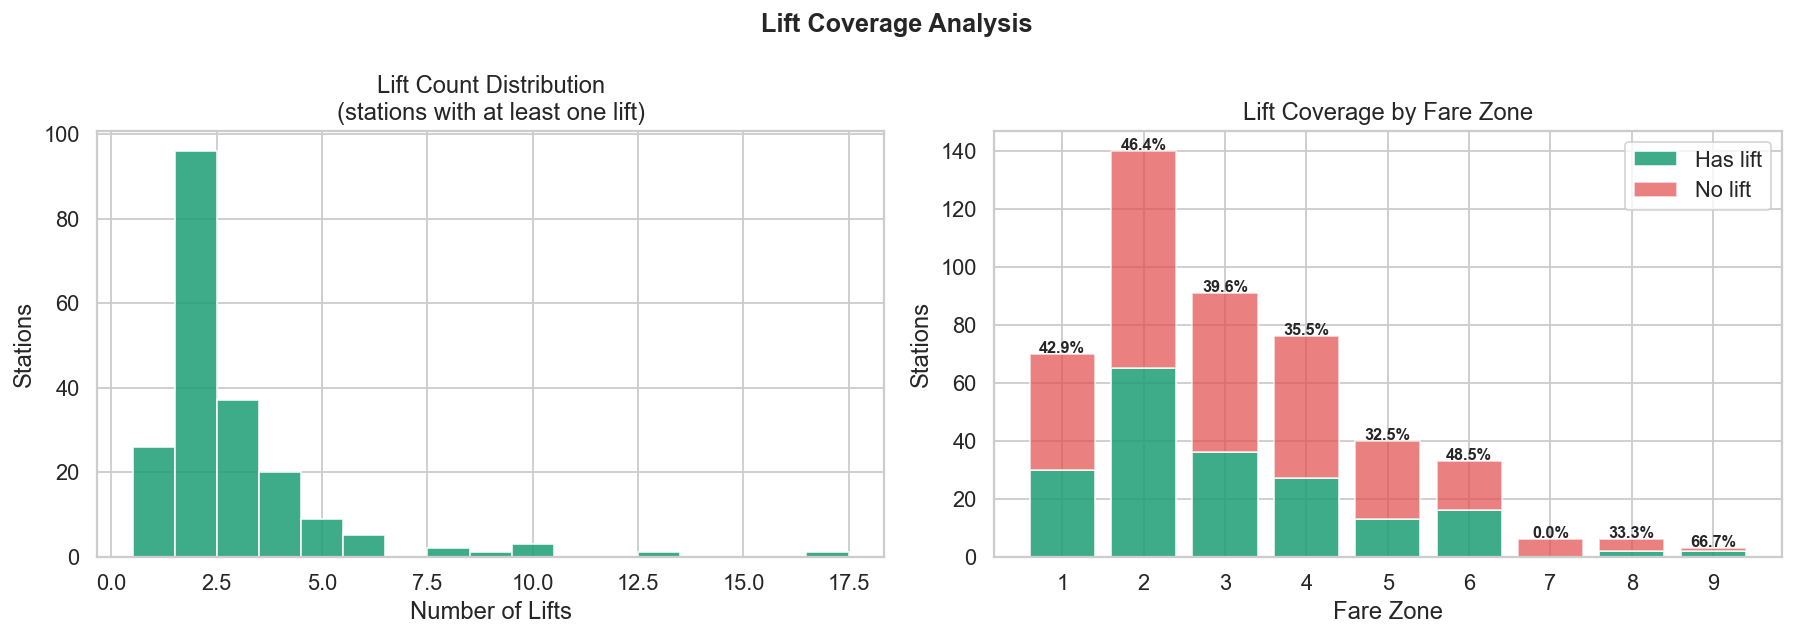

In [6]:
# ── Lift count distribution + coverage by zone ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lift_nz = master[master['TotalLifts'] > 0]['TotalLifts']
axes[0].hist(lift_nz, bins=range(1, int(lift_nz.max())+2),
             color='#1D9E75', edgecolor='white', alpha=0.85, align='left')
axes[0].set_xlabel('Number of Lifts')
axes[0].set_ylabel('Stations')
axes[0].set_title('Lift Count Distribution\n(stations with at least one lift)')

zl = (master[master['PrimaryZone'] != 'Unknown']
      .groupby('PrimaryZone')
      .agg(WithLift=('HasLift','sum'), Total=('HasLift','count'))
      .reset_index())
zl['NoLift'] = zl['Total'] - zl['WithLift']
zl['Pct']    = (zl['WithLift'] / zl['Total'] * 100).round(1)

axes[1].bar(zl['PrimaryZone'], zl['WithLift'],  label='Has lift', color='#1D9E75', alpha=0.85)
axes[1].bar(zl['PrimaryZone'], zl['NoLift'],    label='No lift',  color='#E24B4A', alpha=0.70,
            bottom=zl['WithLift'])
for i, (w, t, p) in enumerate(zip(zl['WithLift'], zl['Total'], zl['Pct'])):
    axes[1].text(i, t + 0.5, f'{p}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Fare Zone')
axes[1].set_ylabel('Stations')
axes[1].set_title('Lift Coverage by Fare Zone')
axes[1].legend()

plt.suptitle('Lift Coverage Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

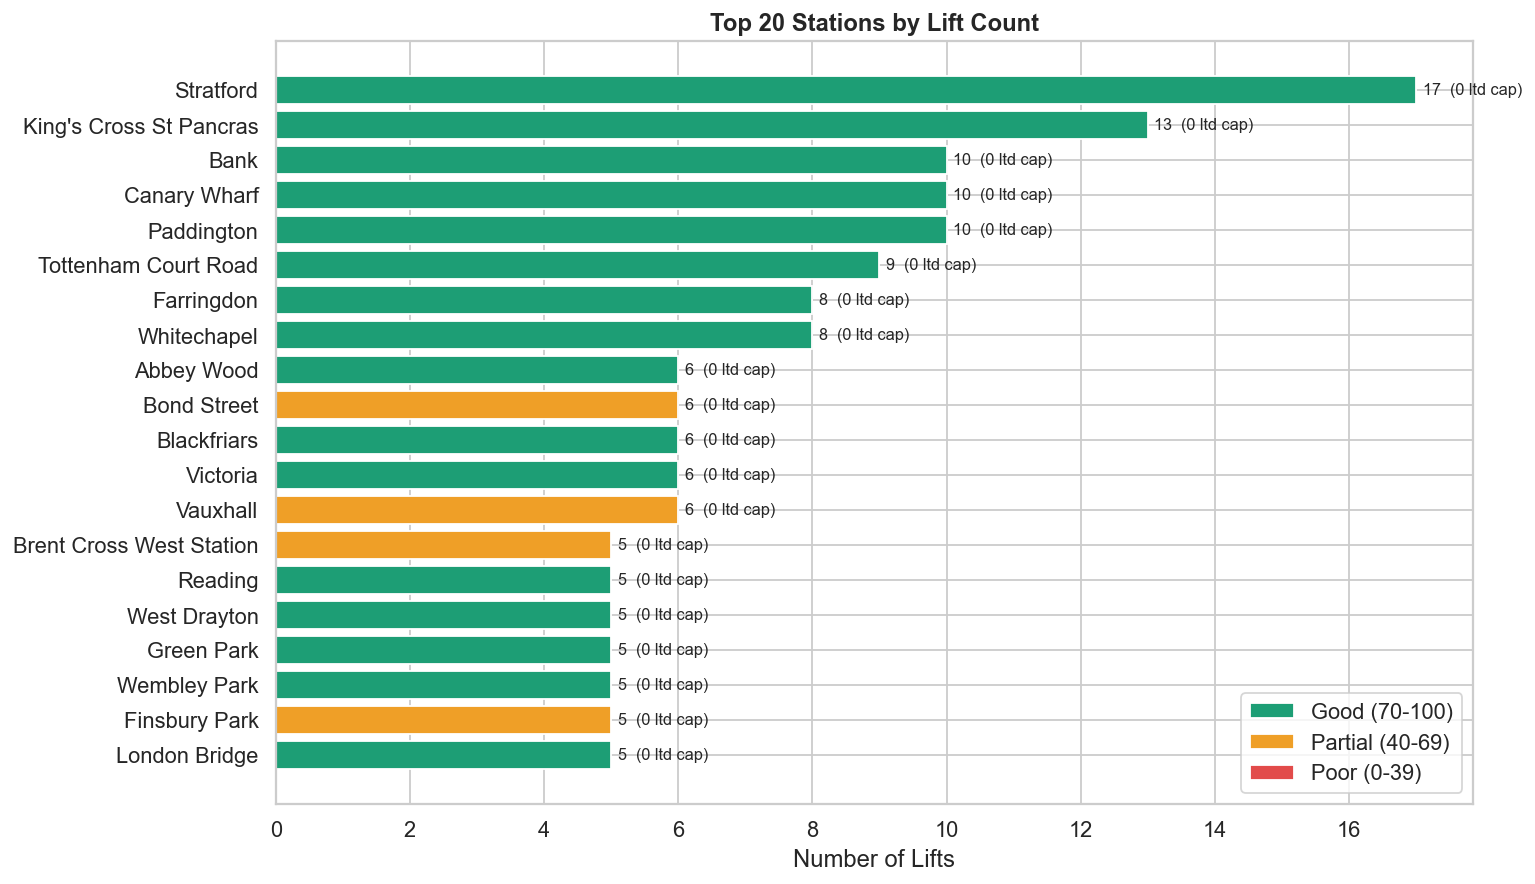

,Name,FareZones,TotalLifts,LimitedCapacityLifts,AccessibilityBand
0,Stratford,2|3,17,0,Good (70-100)
1,King's Cross St Pancras,1,13,0,Good (70-100)
2,Bank,1,10,0,Good (70-100)
3,Canary Wharf,2,10,0,Good (70-100)
4,Paddington,1,10,0,Good (70-100)
5,Tottenham Court Road,1,9,0,Good (70-100)
6,Farringdon,1,8,0,Good (70-100)
7,Whitechapel,2,8,0,Good (70-100)
8,Abbey Wood,4,6,0,Good (70-100)
9,Bond Street,1,6,0,Partial (40-69)


In [7]:
# ── Top 20 stations by lift count ────────────────────────────────
top = (master[master['TotalLifts'] > 0]
       .nlargest(20, 'TotalLifts')
       [['Name','FareZones','TotalLifts','LimitedCapacityLifts','AccessibilityBand']])

fig, ax = plt.subplots(figsize=(12, 7))
colours = [COLOURS.get(b,'#888') for b in top['AccessibilityBand']]
bars = ax.barh(top['Name'], top['TotalLifts'], color=colours, edgecolor='white')
for bar, lim in zip(bars, top['LimitedCapacityLifts']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}  ({int(lim)} ltd cap)', va='center', fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Number of Lifts')
ax.set_title('Top 20 Stations by Lift Count', fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=COLOURS[b], label=b) for b in BAND_ORDER])
plt.tight_layout()
plt.show()

display(top.reset_index(drop=True))

In [8]:
# ── Limited capacity lift risk ───────────────────────────────────
# Stations where ALL lifts are limited capacity = single point of failure
ltd = master[master['LimitedCapacityLifts'] > 0][
    ['Name','FareZones','TotalLifts','LimitedCapacityLifts','AccessibilityScore']
].sort_values('LimitedCapacityLifts', ascending=False)

print(f'Stations with limited-capacity lifts: {len(ltd)}')
print(f'Total limited-capacity lifts        : {ltd["LimitedCapacityLifts"].sum()}')
display(ltd.head(15).reset_index(drop=True))

Stations with limited-capacity lifts: 8
Total limited-capacity lifts        : 18


,Name,FareZones,TotalLifts,LimitedCapacityLifts,AccessibilityScore
0,Limehouse,2,5,5,55.0
1,Crossharbour,2,2,2,55.0
2,Devons Road,2,2,2,55.0
3,Poplar,2,2,2,55.0
4,South Quay,2,2,2,55.0
5,West India Quay,2,2,2,55.0
6,Tower Gateway,1,2,2,55.0
7,Hounslow West,5,1,1,70.0


In [9]:
# ── Stations with NO lift — gap list ─────────────────────────────
no_lift = master[master['TotalLifts'] == 0].sort_values('AccessibilityScore')[
    ['Name','FareZones','LinesServed','AccessibilityScore','AccessibilityBand']
]
print(f'Stations with no lift: {len(no_lift)}')
display(no_lift.reset_index(drop=True))

Stations with no lift: 308


,Name,FareZones,LinesServed,AccessibilityScore,AccessibilityBand
0,West Sutton,5,national-rail,0.0,Poor (0-39)
1,Mill Hill Broadway,4,national-rail,0.0,Poor (0-39)
2,Loughborough Junction,2,national-rail,0.0,Poor (0-39)
3,Morden South,4,national-rail,0.0,Poor (0-39)
4,Wimbledon Chase,3,national-rail,0.0,Poor (0-39)
...,...,...,...,...,...
303,Stanmore,5,jubilee,45.0,Partial (40-69)
304,Uxbridge,6,"metropolitan, piccadilly",45.0,Partial (40-69)
305,Beckenham Junction,4|Trams fare zone,"national-rail, tram",48.0,Partial (40-69)
306,Euston,1,"lioness, national-rail, northern, victoria",51.0,Partial (40-69)
